# Protocol 1: Calculating Assembly Indices

This notebook partially recapitulates Figure 1 of [Sharma et al. (2023)](https://doi.org/10.1038/s41586-023-06600-9), which introduced the molecular assembly index.

It calculates the molecular assembly index for a set of amino acids, both individually and as a joint system whose members can share substructures, then applies the same idea to a plain character string.

## Running it

Run this notebook from its own directory so the figures it saves land beside
it. In JupyterLab:

```bash
cd examples/protocols/1
jupyter lab protocol_1.ipynb
```

Or headlessly, which is how the committed outputs were produced:

```bash
cd examples/protocols/1
jupyter nbconvert --to notebook --execute --inplace protocol_1.ipynb
```

Use **Run All** so the total-time cell at the end measures the whole workflow.

This protocol needs no external data: the molecules and the string are defined below.

## Timing

The heavy steps below start with the `%%time` cell magic. Read the **Wall
time** it reports. The parallel steps spread work across every CPU core, and
`%%time` counts CPU time for the notebook's own process only, not the worker
pool, so wall time is the figure to compare. The times shown were
recorded on a 28-core machine and will differ on yours.

In [1]:
%matplotlib inline
import os
import time

import matplotlib.pyplot as plt

import assemblytheorytools as att

print(f"CPU cores available: {os.cpu_count()}")
_t_start = time.perf_counter()

CPU cores available: 28


## Parameters

In [2]:
# Per-search timeout in seconds. In exact mode a search that exceeds this
# returns a negative value rather than an upper bound, and we treat that as a
# failure below.
TIMEOUT = 5.0 * 60.0

# Input molecules as name -> SMILES: five amino acids, as in Sharma et al. (2023).
MOLECULES = {
    'Glycine': 'C(C(=O)O)N',
    'Alanine': 'C[C@@H](C(=O)O)N',
    'Proline': 'C1C[C@H](NC1)C(=O)O',
    'Valine': 'CC(C)[C@@H](C(=O)O)N',
    'Histidine': 'O=C([C@H](CC1=CNC=N1)N)O',
}

# Input string for the string-assembly demonstration in Part B.
STRING = "gggfhhhvg"

## Part A: molecular assembly indices

### 1. Input molecules

Convert each SMILES string to the NetworkX graph the assembly calculator works
on. `att.smi_to_nx` parses the SMILES with RDKit and builds the molecular graph.

In [3]:
graphs = [att.smi_to_nx(smi) for smi in MOLECULES.values()]

print(f"Input SMILES strings: {list(MOLECULES.values())}")

Input SMILES strings: ['C(C(=O)O)N', 'C[C@@H](C(=O)O)N', 'C1C[C@H](NC1)C(=O)O', 'CC(C)[C@@H](C(=O)O)N', 'O=C([C@H](CC1=CNC=N1)N)O']


### 2. Individual assembly indices

Compute each molecule's assembly index on its own, in parallel across all
cores. Hydrogens are stripped, and exact mode is requested: a search that times
out returns `-1`, which we detect and reject rather than reporting an upper
bound as if it were exact.

In [4]:
%%time
ai_i = att.calculate_assembly_index_parallel(
    graphs,
    settings={'strip_hydrogen': True, 'timeout': TIMEOUT, 'exact': True},
)[0]

if any(ai < 0 for ai in ai_i):
    raise RuntimeError("An individual assembly search timed out before finding an exact result")

print("Individual assembly indices:")
for name, ai in zip(MOLECULES.keys(), ai_i):
    print(f"    {name}: {ai}")

Individual assembly indices:
    Glycine: 3
    Alanine: 4
    Proline: 6
    Valine: 5
    Histidine: 9
CPU times: user 14.5 ms, sys: 5.18 ms, total: 19.7 ms
Wall time: 965 ms


### 3. Joint assembly index

Combine the individual graphs into one disconnected graph and compute the
*joint* assembly index. The joint calculation finds substructures (virtual
objects) that can be shared across the whole set, so the joint index is
generally smaller than the sum of the individual indices.

In [5]:
%%time
combined_graph = att.join_graphs(graphs)

jai, virt_obj, pathway = att.calculate_assembly_index(
    combined_graph,
    strip_hydrogen=True,
    timeout=TIMEOUT,
    exact=True,
)
if jai < 0:
    raise RuntimeError("The joint assembly search timed out before finding an exact result")

# Convert the virtual objects (graphs) back to SMILES for display.
virt_smiles = [att.nx_to_smi(vo, add_hydrogens=False) for vo in virt_obj]

CPU times: user 8.16 ms, sys: 40 μs, total: 8.2 ms
Wall time: 14 ms


### 4. Output

In [6]:
print(f"Joint assembly index: {jai}")
print("Virtual objects in pathway:")
for smi in virt_smiles:
    print(f"    {smi}")

Joint assembly index: 12
Virtual objects in pathway:
    CC
    C1=CNC=N1
    C=NC
    O=C(O)C1CCCN1
    C=O
    CO
    NCC(=O)O
    CC(C)C(N)C(=O)O
    CN=CN
    CN=CNC
    C=N
    NC(CC1=CNC=N1)C(=O)O
    CN
    CCN
    O=CO
    CCC(N)C(=O)O
    CC(N)C(=O)O
    C=C


### 5. Pathway plot

Draw the joint assembly pathway. `show_icons` renders the molecular structure
at each node, and `crossmin_long` lays the directed acyclic graph out to
minimise edge crossings. Rendering the icons is the slow part, so this cell is
timed.

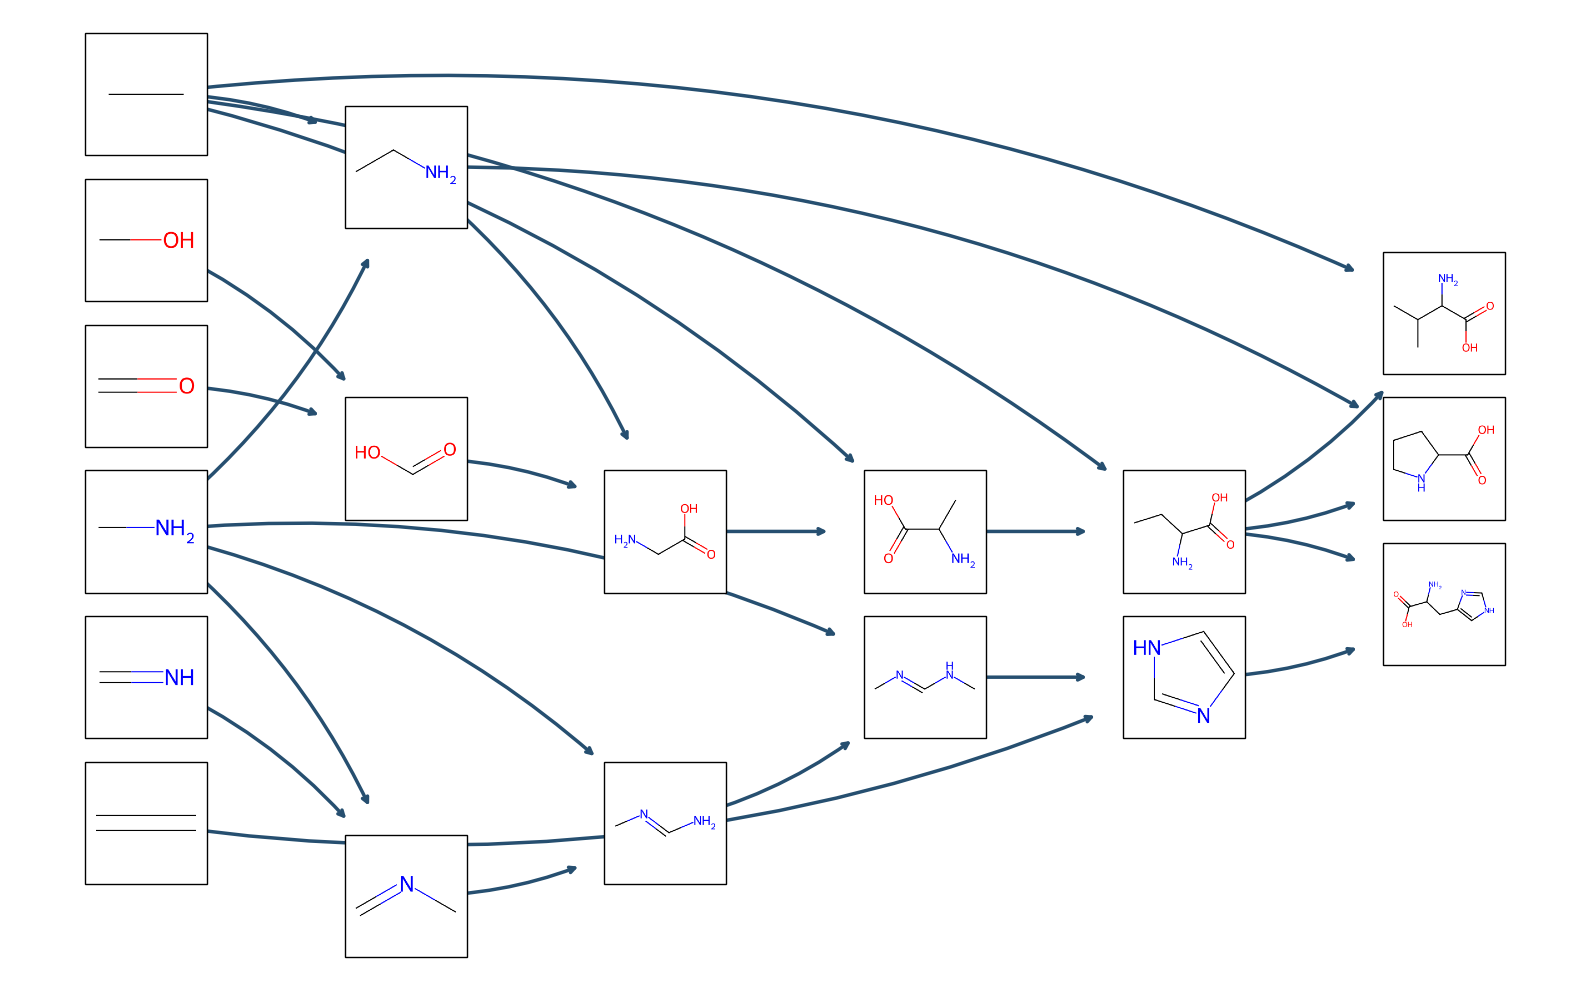

CPU times: user 693 ms, sys: 43.1 ms, total: 736 ms
Wall time: 742 ms


In [7]:
%%time
fig, ax = att.plot_pathway(
    pathway,
    show_icons=True,
    frame_on=True,
    fig_size=(16, 10),
    layout_style='crossmin_long',
)
plt.savefig("mol_pathway_example.svg")
plt.savefig("mol_pathway_example.png", dpi=300)
plt.show()

*The joint assembly pathway for the combined molecular system, showing the virtual objects shared between the inputs.*

## Part B: string assembly index

### 1. Input string and calculation

The same assembly machinery works on arbitrary sequences. For a string the
virtual objects are reused substrings. `directed=False` treats the string as an
undirected sequence.

In [8]:
%%time
ai, virt_obj, pathway = att.calculate_string_assembly_index(STRING, directed=False)

print(f"Assembly index: {ai}")
print(f"Virtual objects in pathway: {virt_obj}")

Assembly index: 8
Virtual objects in pathway: ['f', 'gggf', 'gggfhh', 'g', 'ggg', 'gggfhhhvg', 'h', 'v', 'gggfh', 'gggfhhh', 'gggfhhhv', 'gg']
CPU times: user 1.65 ms, sys: 26 μs, total: 1.68 ms
Wall time: 2.3 ms


### 2. String pathway plot

`plot_type="string"` renders each node as its substring rather than a molecular
icon.

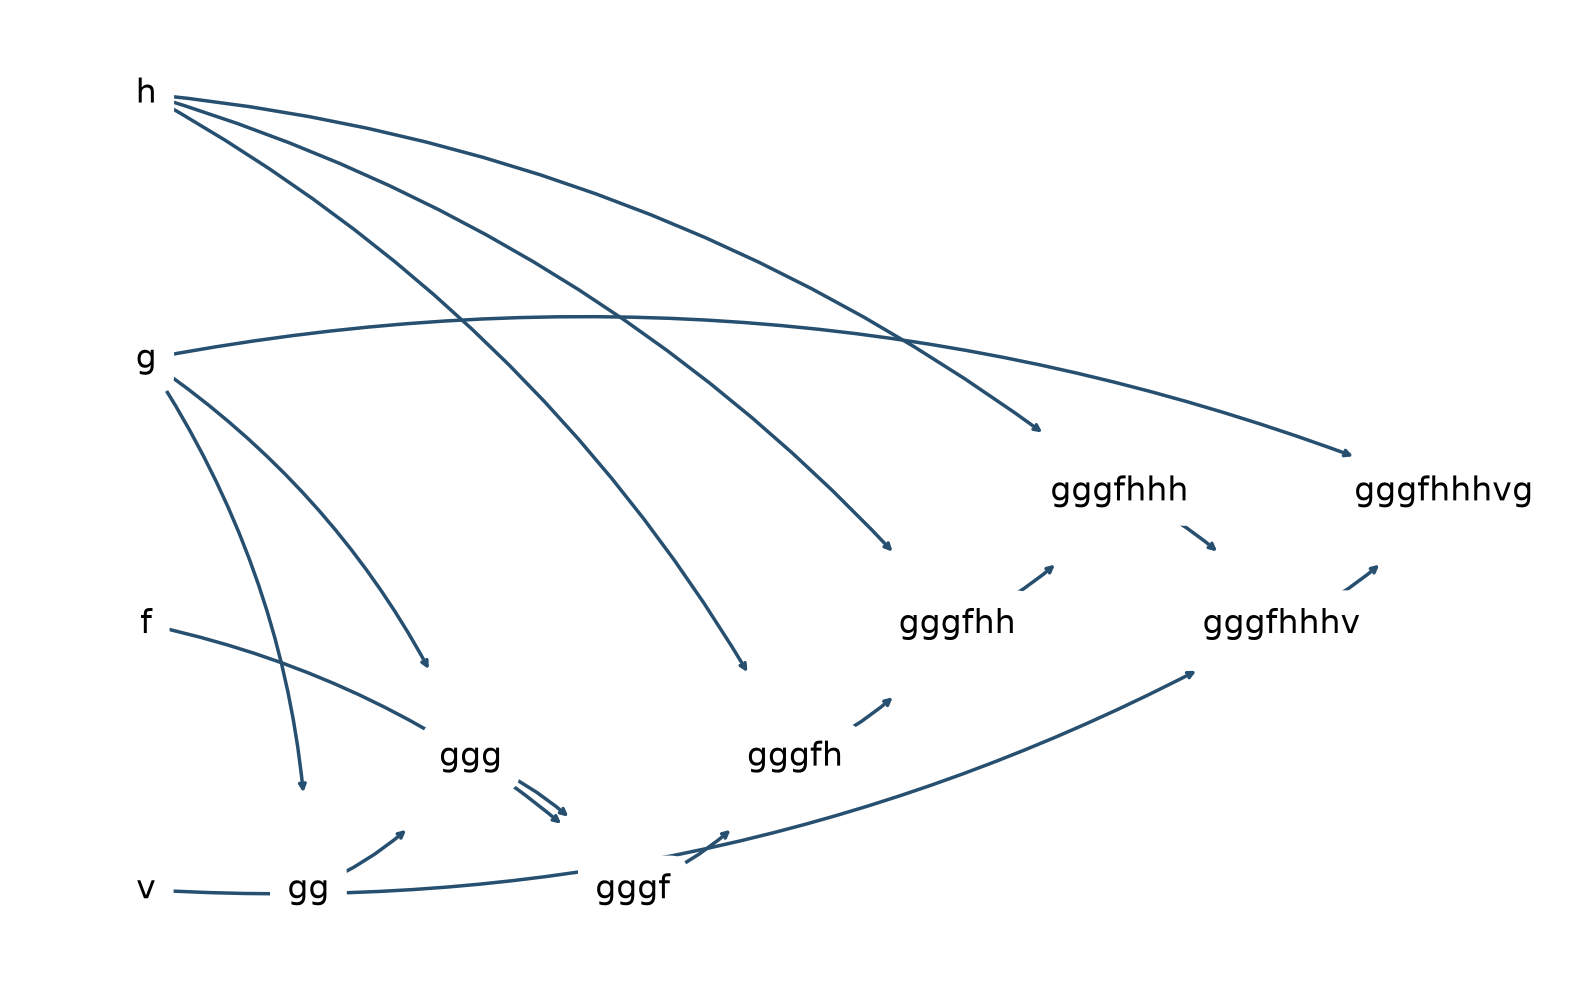

In [9]:
fig, ax = att.plot_pathway(
    pathway,
    plot_type="string",
    font_size=24,
    fig_size=(16, 10),
    layout_style='crossmin_long',
)
plt.savefig("str_pathway_example.svg")
plt.savefig("str_pathway_example.png", dpi=300)
plt.show()

*The assembly pathway for the string `gggfhhhvg`, with the reused substrings appearing as virtual objects.*

In [10]:
print(f"Total wall time: {time.perf_counter() - _t_start:.1f} s")

Total wall time: 2.1 s


## Related documentation

* [Molecules guide](https://assemblytheorytools.readthedocs.io/en/latest/guide/molecules.html) — single and joint molecular assembly.
* [Strings guide](https://assemblytheorytools.readthedocs.io/en/latest/guide/strings.html) — string assembly indices.
* [Pathways guide](https://assemblytheorytools.readthedocs.io/en/latest/guide/pathways.html) — plotting and inspecting the result.